In [1]:
# ============================
# CELL 1: COMMON DEFINITIONS
# ============================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
from google.colab import drive
drive.mount('/content/drive')
# ===========================
# Reproducibility
# ===========================
torch.manual_seed(42)
torch.cuda.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
# ==========================
# Device
# ==========================
if torch.cuda.is_available():
  device = 'cuda'
  print(torch.cuda.get_device_name(0))
else:
  device = 'cpu'
print('using device:', device)
# ==========================
# PINN Model
# ==========================
LAYERS = 8
NEURONS = 256
class PINN(nn.Module):
  def __init__(self, layers=LAYERS, neurons=NEURONS):
    super().__init__()
    net = [nn.Linear(3, neurons), nn.Tanh()]
    for _ in range(layers - 1):
      net += [nn.Linear(neurons, neurons), nn.Tanh()]
    net += [nn.Linear(neurons, 1)]
    self.net = nn.Sequential(*net)
    self.initialize_weights()

  def initialize_weights(self):
    for m in self.modules():
      if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
          nn.init.zeros_(m.bias)
  def forward(self, x):
    return self.net(x)
model = PINN().to(device)
# =========================
# Hyperparameters
# =========================
N_f = 10000
N_i = 5000
T_final = 8
adam_epochs = 20000
lbfgs_epochs = 2000
w_pde, w_ic , w_eik = 1.0, 10.0, 0.0001
# =========================
# Velocity Field
# =========================
def velocity_field(x, y, t):
  factor = torch.cos(np.pi * t)
  u = -torch.sin(np.pi * x)**2 * torch.sin(2 * np.pi * y) * factor
  v = torch.sin(np.pi * y)**2 * torch.sin(2 * np.pi * x) * factor
  return u, v
# =========================
# Initial Condition
# =========================
def initial_condition(x, y):
  xc, yc, r = 0.5, 0.75, 0.15
  return torch.sqrt((x - xc)**2 + (y - yc)**2) - r
# =========================
# Sample Points
# =========================
torch.manual_seed(100)
torch.cuda.manual_seed(100)

X_f = torch.rand(N_f, 3, dtype=torch.float32, device=device).requires_grad_(True)

x_i = torch.rand(N_i, 1, dtype=torch.float32, device=device)
y_i = torch.rand(N_i, 1, dtype=torch.float32, device=device)
t_i = torch.zeros(N_i, 1, dtype=torch.float32, device=device)
X_i = torch.cat([x_i, y_i, t_i], dim=1)
# =========================
# Loss Function
# ========================
def physics_loss(X_f, X_i):
  # PDE Loss
  phi = model(X_f)
  grad_phi = torch.autograd.grad(phi, X_f, grad_outputs=torch.ones_like(phi), create_graph=True)[0]
  phi_x, phi_y, phi_t = grad_phi[:, 0:1], grad_phi[:, 1:2], grad_phi[:, 2:3]
  u, v = velocity_field(X_f[:, 0:1], X_f[:, 1:2], X_f[:, 2:3])
  f_pde = phi_t + T_final * (u * phi_x + v * phi_y)
  loss_pde = torch.mean(f_pde**2)
  # Initial Condition Loss
  phi_true = initial_condition(X_i[:, 0:1], X_i[:, 1:2])
  phi_pred = model(X_i)
  loss_ic = torch.mean((phi_true - phi_pred)**2)
  # Eikonal Loss
  norm_phi = torch.sqrt(phi_x**2 + phi_y**2 + 1e-8)
  loss_eik = torch.mean((norm_phi - 1)**2)

  total_loss = w_pde * loss_pde + w_ic * loss_ic + w_eik * loss_eik
  return loss_pde, loss_ic, loss_eik, total_loss

Mounted at /content/drive
Tesla T4
using device: cuda


In [ ]:
# ========================
# Training
# ========================
optimizer_adam = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer_adam, step_size=1000, gamma=0.9)
start_time = time.time()
history = {'epoch': [], 'total': [], 'pde': [], 'ic': [], 'eik': []}
# Adam optimizer
for epoch in range(adam_epochs):
    optimizer_adam.zero_grad()
    loss_pde, loss_ic, loss_eik, loss = physics_loss(X_f, X_i)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer_adam.step()
    scheduler.step()
    lr = scheduler.get_last_lr()[0]

    history['epoch'].append(epoch)
    history['total'].append(loss.item())
    history['pde'].append(loss_pde.item())
    history['ic'].append(loss_ic.item())
    history['eik'].append(loss_eik.item())

    if epoch % 2000 == 0:
      print(f"Adam Iter {epoch} | total loss {loss.item():.3e} | pde loss {loss_pde.item():.3e} | ic loss {loss_ic.item():.3e} | eik loss {loss_eik.item():.3e} | LR {lr:.3e}")
    elif epoch == adam_epochs - 1:
      print(f"Adam Iter {adam_epochs} | total loss {loss.item():.3e} | pde loss {loss_pde.item():.3e} | ic loss {loss_ic.item():.3e} | eik loss {loss_eik.item():.3e} | LR {lr:.3e}")

# LBFGS training
print("LBFGS Optimizer Starting...")
optimizer_lbfgs = optim.LBFGS(model.parameters(), lr=1.0,  line_search_fn='strong_wolfe')
loss_store = {}
for epoch in range(lbfgs_epochs):
    def closure():
        optimizer_lbfgs.zero_grad()
        loss_pde, loss_ic, loss_eik, loss = physics_loss(X_f, X_i)
        loss.backward()
        loss_store['total'] = loss.item()
        loss_store['pde'] = loss_pde.item()
        loss_store['ic'] = loss_ic.item()
        loss_store['eik'] = loss_eik.item()
        return loss
    optimizer_lbfgs.step(closure)

    history['epoch'].append(adam_epochs + epoch)
    history['total'].append(loss_store['total'])
    history['pde'].append(loss_store['pde'])
    history['ic'].append(loss_store['ic'])
    history['eik'].append(loss_store['eik'])
    if epoch % 200 == 0:
      print(f"LBFGS epoch {epoch} | total loss {loss_store['total']:.3e} | pde loss {loss_store['pde']:.3e} | ic loss {loss_store['ic']:.3e} | eik loss {loss_store['eik']:.3e}")
    elif epoch == lbfgs_epochs - 1:
      print(f"LBFGS epoch {lbfgs_epochs} | total loss {loss_store['total']:.3e} | pde loss {loss_store['pde']:.3e} | ic loss {loss_store['ic']:.3e} | eik loss {loss_store['eik']:.3e}")
end_time = time.time()
total_training_time = (end_time - start_time)/60
print(f"Full training done in {total_training_time:.1f} minutes")

# Save checkpoint
checkpoint_path = '/content/drive/MyDrive/RV_S3_exp01.pth'
torch.save({
    'model_state_dict':           model.state_dict(),
    'optimizer_adam_state_dict':  optimizer_adam.state_dict(),
    'optimizer_lbfgs_state_dict': optimizer_lbfgs.state_dict(),
    'training_time':              f'{total_training_time:.1f} minutes',
    'history':                    history
}, checkpoint_path)
print(f"Saved to {checkpoint_path}")

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Adam Iter 0 | total loss 3.609e+00 | pde loss 7.723e-01 | ic loss 2.836e-01 | eik loss 4.251e-01 | LR 1.000e-03
Adam Iter 2000 | total loss 8.717e-02 | pde loss 6.010e-02 | ic loss 2.696e-03 | eik loss 1.027e+00 | LR 8.100e-04
Adam Iter 4000 | total loss 2.997e-02 | pde loss 1.962e-02 | ic loss 1.017e-03 | eik loss 1.697e+00 | LR 6.561e-04
Adam Iter 6000 | total loss 2.169e-02 | pde loss 1.683e-02 | ic loss 4.588e-04 | eik loss 2.690e+00 | LR 5.314e-04
Adam Iter 8000 | total loss 1.358e-02 | pde loss 1.172e-02 | ic loss 1.557e-04 | eik loss 3.057e+00 | LR 4.305e-04
Adam Iter 10000 | total loss 1.024e-02 | pde loss 8.644e-03 | ic loss 1.277e-04 | eik loss 3.169e+00 | LR 3.487e-04
Adam Iter 12000 | total loss 5.481e-03 | pde loss 4.232e-03 | ic loss 9.144e-05 | eik loss 3.348e+00 | LR 2.824e-04
Adam Iter 14000 | total loss 1.887e-03 | pde loss 1.162e-03 | ic loss 3.612e-05 | eik loss 3.638e+00 | LR 2.288e-04
Adam Iter 16000 | total loss 1.335e-03 | pde loss 7.364e-04 | ic loss 2.401e-05 

In [2]:
# ===========================
# Load Model
# ===========================
checkpoint = torch.load('/content/drive/MyDrive/RV_S3_exp01.pth', map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model Loaded Successfully!")

Model Loaded Successfully!


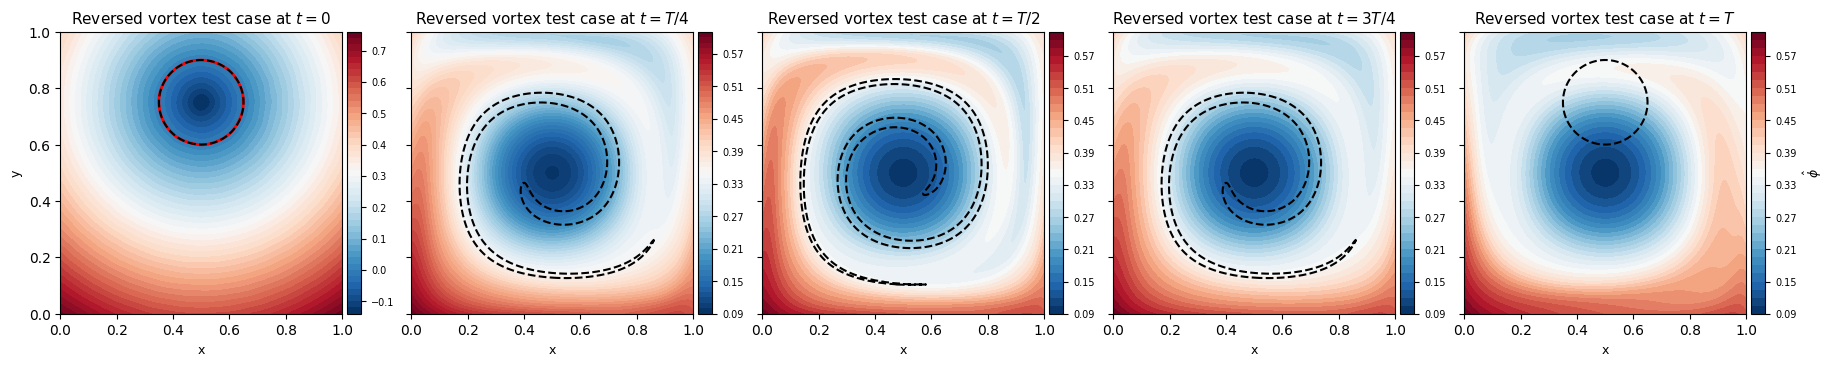

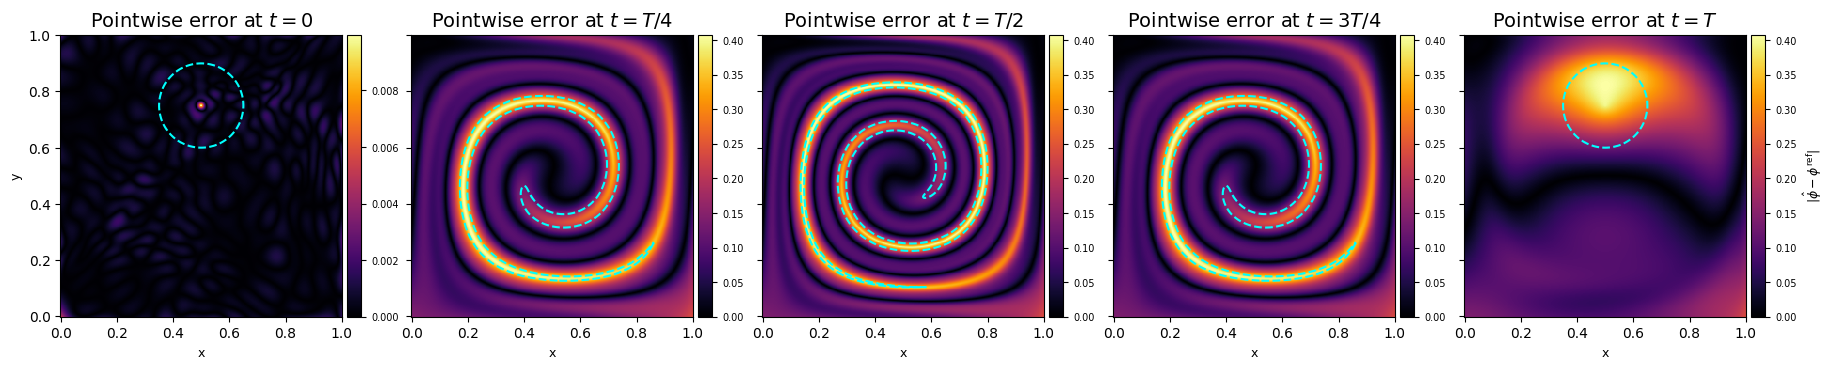


Snapshot           abs L2   rel L2 (%)     mass abs     MAPE (%)
--------------------------------------------------------------
t=0.00          4.78e-04        0.14%      1.83e-04        0.26%
t=2.00          1.45e-01       41.67%      7.07e-02      100.00%
t=4.00          1.45e-01       41.68%      7.07e-02      100.00%
t=6.00          1.45e-01       41.68%      7.07e-02      100.00%
t=8.00          1.45e-01       41.67%      7.07e-02      100.00%
--------------------------------------------------------------
avg              1.16e-01       33.37%      5.66e-02       80.05%


In [3]:
# ==============================================================
# CELL 5: EVALUATION
# Figure 4a: phi field (1 row x 5 cols, per-snapshot colorbar)
# Figure 4b: error field (1 row x 5 cols, per-snapshot colorbar)
# ==============================================================
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from mpl_toolkits.axes_grid1 import ImageGrid

times = [0.0, T_final/4, T_final/2, 3*T_final/4, T_final]
nx = 300

x_1d = np.linspace(0, 1, nx)
y_1d = np.linspace(0, 1, nx)
X, Y = np.meshgrid(x_1d, y_1d)
dx = dy = x_1d[1] - x_1d[0]

def exact_phi_at_t(X_grid, Y_grid, t_target):
    xc, yc, r = 0.5, 0.75, 0.15
    if np.isclose(t_target, 0.0):
        return np.sqrt((X_grid - xc)**2 + (Y_grid - yc)**2) - r
    x_flat = X_grid.flatten()
    y_flat = Y_grid.flatten()
    N = len(x_flat)
    def rhs_back(t, xy_all):
        x_all = xy_all[:N]
        y_all = xy_all[N:]
        factor = np.cos(np.pi * t / T_final)
        u = -np.sin(np.pi * x_all)**2 * np.sin(2 * np.pi * y_all) * factor
        v =  np.sin(np.pi * y_all)**2 * np.sin(2 * np.pi * x_all) * factor
        return np.concatenate([u, v])
    xy0 = np.concatenate([x_flat, y_flat])
    sol = solve_ivp(rhs_back, [t_target, 0.0], xy0,
                    method='RK45', rtol=1e-8, atol=1e-10)
    x0 = sol.y[:N, -1]
    y0 = sol.y[N:, -1]
    phi0 = np.sqrt((x0 - xc)**2 + (y0 - yc)**2) - r
    return phi0.reshape(X_grid.shape)

# ── Exact reference area (Mullins Eq. 35-36) ──────────────────
# Divergence-free flow conserves area exactly at all t.
# A_exact = π r² is the analytical constant reference — never changes.
A_exact = np.pi * 0.15**2

# Collect data
phi_preds, phi_refs = [], []
l2_abs_list, l2_rel_list, mass_abs_list, mass_ape_list = [], [], [], []

for t_val in times:
    t_norm = t_val / T_final
    XYT = torch.tensor(
        np.stack([X.flatten(), Y.flatten(),
                  t_norm * np.ones(X.size)], axis=1),
        dtype=torch.float32, device=device)
    with torch.no_grad():
        phi_pred = model(XYT).cpu().numpy().reshape(nx, nx)
    phi_ref = exact_phi_at_t(X, Y, t_val)
    phi_preds.append(phi_pred)
    phi_refs.append(phi_ref)

    # ── L² errors (unchanged) ──
    l2_abs = np.sqrt(np.mean((phi_pred - phi_ref)**2))
    l2_rel = np.sqrt(np.sum((phi_pred - phi_ref)**2)) / np.sqrt(np.sum(phi_ref**2)) * 100

    # ── Mass / area errors (Mullins-exact formula) ──
    A_pred   = np.sum(phi_pred < 0) * dx * dy          # predicted enclosed area
    mass_abs = abs(A_pred - A_exact)                    # absolute area error
    mass_ape = abs(A_pred - A_exact) / A_exact * 100   # MAPE (%) — matches Mullins

    l2_abs_list.append(l2_abs)
    l2_rel_list.append(l2_rel)
    mass_abs_list.append(mass_abs)
    mass_ape_list.append(mass_ape)

errors = [np.abs(phi_preds[i] - phi_refs[i]) for i in range(5)]
tlabels = [r'$t=0$', r'$t=T/4$', r'$t=T/2$', r'$t=3T/4$', r'$t=T$']

# ══════════════════════════════════════════════════════
# Figure 4a: Predicted φ field
# ══════════════════════════════════════════════════════
fig1 = plt.figure(figsize=(22, 5))
grid1 = ImageGrid(fig1, 111, nrows_ncols=(1, 5), axes_pad=0.5,
                  cbar_mode='each', cbar_location='right',
                  cbar_pad=0.05, cbar_size='5%')

for i, ax in enumerate(grid1):
    im = ax.contourf(X, Y, phi_preds[i], levels=50, cmap='RdBu_r')
    ax.contour(X, Y, phi_preds[i], levels=[0], colors='red', linewidths=2)
    ax.contour(X, Y, phi_refs[i],  levels=[0], colors='black', linewidths=1.5,
               linestyles='--')
    ax.set_title(f'Reversed vortex test case at {tlabels[i]}', fontsize=11)
    ax.set_aspect('equal')
    ax.set_xlabel('x', fontsize=9)
    if i == 0: ax.set_ylabel('y', fontsize=9)
    cb = grid1.cbar_axes[i].colorbar(im)
    cb.ax.tick_params(labelsize=7)
    if i == 4: cb.set_label(r'$\hat{\phi}$', fontsize=9)

#plt.savefig('/content/drive/MyDrive/fig_RV_S3_exp01_phi.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# ══════════════════════════════════════════════════════
# Figure 4b: Pointwise error
# ══════════════════════════════════════════════════════
fig2 = plt.figure(figsize=(22, 5))
grid2 = ImageGrid(fig2, 111, nrows_ncols=(1, 5), axes_pad=0.5,
                  cbar_mode='each', cbar_location='right',
                  cbar_pad=0.05, cbar_size='5%')

for i, ax in enumerate(grid2):
    im = ax.pcolormesh(X, Y, errors[i], cmap='inferno',
                       vmin=0, vmax=errors[i].max(), shading='auto')
    ax.contour(X, Y, phi_refs[i], levels=[0], colors='cyan', linewidths=1.5,
               linestyles='--')
    ax.set_title(f'Pointwise error at {tlabels[i]}', fontsize=14)
    ax.set_aspect('equal')
    ax.set_xlabel('x', fontsize=9)
    if i == 0: ax.set_ylabel('y', fontsize=9)
    cb = grid2.cbar_axes[i].colorbar(im)
    cb.ax.tick_params(labelsize=7)
    if i == 4: cb.set_label(r'$|\hat{\phi}-\phi^{\rm ref}|$', fontsize=9)

#plt.savefig('/content/drive/MyDrive/fig_RV_S3_exp01_errors.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Summary
print(f"\n{'Snapshot':<12} {'abs L2':>12} {'rel L2 (%)':>12} {'mass abs':>12} {'MAPE (%)':>12}")
print('-' * 62)
for t_val, l2a, l2r, ma, ape in zip(times, l2_abs_list, l2_rel_list, mass_abs_list, mass_ape_list):
    print(f't={t_val:<8.2f}  {l2a:>12.2e}  {l2r:>10.2f}%  {ma:>12.2e}  {ape:>10.2f}%')
print('-' * 62)
print(f"{'avg':<12} {np.mean(l2_abs_list):>12.2e}  {np.mean(l2_rel_list):>10.2f}%  "
      f"{np.mean(mass_abs_list):>12.2e}  {np.mean(mass_ape_list):>10.2f}%")

In [4]:
import csv
import numpy as np

# CONFIG
EXP_ID           = 'RV_S3_exp01'
BENCHMARK        = 'RV'
ARCHITECTURE     = 'MLP'
SCHEDULER        = 'StepLR'
SCHEDULER_PARAMS = 'step_1000_gamma_0.9'
LBFGS_HISTORY    = 100
T_NORMALIZED     = True
CSV_PATH         = '/content/drive/MyDrive/RV_S3_mullins_comparison.csv'


CAUSAL           = False
M_CHUNKS_VAL     = 0
EPS_CAUSAL_VAL   = 0
RAD_FREQ_VAL     = 0
RAD_CANDIDATES_VAL = 0
RAD_K_VAL        = 0
RAD_C_VAL        = 0
RAR_FREQ_VAL     = 0
RAR_CANDIDATES_VAL = 0
RAR_ADD_VAL      = 0

row = {
    'exp_id':            EXP_ID,
    'benchmark':         BENCHMARK,
    'architecture':      ARCHITECTURE,
    'N_f':               N_f,
    'N_i':               N_i,
    'layers':            LAYERS,
    'neurons':           NEURONS,
    # Causal settings
    'causal':            CAUSAL,
    'm_chunks':          M_CHUNKS_VAL,
    'eps_causal':        EPS_CAUSAL_VAL,
    # RAD settings
    'rad_freq':          RAD_FREQ_VAL,
    'rad_candidates':    RAD_CANDIDATES_VAL,
    'rad_k':             RAD_K_VAL,
    'rad_c':             RAD_C_VAL,
    # RAR-G settings
    'rar_freq':          RAR_FREQ_VAL,
    'rar_candidates':    RAR_CANDIDATES_VAL,
    'rar_add':           RAR_ADD_VAL,
    # Loss weights
    'w_pde':             w_pde,
    'w_ic':              w_ic,
    'w_eik':             w_eik,
    # Training
    'adam_epochs':       adam_epochs,
    'lbfgs_epochs':      lbfgs_epochs,
    'lbfgs_history':     LBFGS_HISTORY,
    'scheduler':         SCHEDULER,
    'scheduler_params':  SCHEDULER_PARAMS,
    't_normalized':      T_NORMALIZED,
    # abs L2 per snapshot
    'L2abs_t0':          f'{l2_abs_list[0]:.2e}',
    'L2abs_tT4':         f'{l2_abs_list[1]:.2e}',
    'L2abs_tT2':         f'{l2_abs_list[2]:.2e}',
    'L2abs_t3T4':        f'{l2_abs_list[3]:.2e}',
    'L2abs_tT':          f'{l2_abs_list[4]:.2e}',
    'avg_L2abs':         f'{np.mean(l2_abs_list):.2e}',
    # rel L2 (%) per snapshot
    'L2rel(%)_t0':       f'{l2_rel_list[0]:.2f}%',
    'L2rel(%)_tT4':      f'{l2_rel_list[1]:.2f}%',
    'L2rel(%)_tT2':      f'{l2_rel_list[2]:.2f}%',
    'L2rel(%)_t3T4':     f'{l2_rel_list[3]:.2f}%',
    'L2rel(%)_tT':       f'{l2_rel_list[4]:.2f}%',
    'avg_L2rel(%)':      f'{np.mean(l2_rel_list):.2f}%',
    # mass abs error per snapshot
    'mass_t0':           f'{mass_abs_list[0]:.2e}',
    'mass_tT4':          f'{mass_abs_list[1]:.2e}',
    'mass_tT2':          f'{mass_abs_list[2]:.2e}',
    'mass_t3T4':         f'{mass_abs_list[3]:.2e}',
    'mass_tT':           f'{mass_abs_list[4]:.2e}',
    'avg_mass':          f'{np.mean(mass_abs_list):.2e}',
    # MAPE (%) per snapshot
    'MAPE(%)_t0':        f'{mass_ape_list[0]:.2f}%',
    'MAPE(%)_tT4':       f'{mass_ape_list[1]:.2f}%',
    'MAPE(%)_tT2':       f'{mass_ape_list[2]:.2f}%',
    'MAPE(%)_t3T4':      f'{mass_ape_list[3]:.2f}%',
    'MAPE(%)_tT':        f'{mass_ape_list[4]:.2f}%',
    'avg_MAPE(%)':       f'{np.mean(mass_ape_list):.2f}%',
    'training_time':     checkpoint['training_time'],
}

write_header = False
try:
    with open(CSV_PATH, 'r') as f:
        write_header = (f.read(1) == '')
except FileNotFoundError:
    write_header = True

with open(CSV_PATH, 'a', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=row.keys())
    if write_header:
        writer.writeheader()
    writer.writerow(row)

print(f'Row appended → {CSV_PATH}')

Row appended → /content/drive/MyDrive/RV_S3_mullins_comparison.csv
